In [ ]:
# Install dependencies
!apt-get install -y coinor-libipopt-dev
!pip install pyomo

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
coinor-libipopt-dev is already the newest version (3.11.9-2.2build5).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

In [ ]:
# Check IPOPT is installed
!which ipopt
!ipopt --version

bin/ipopt
Ipopt 3.13.2 (x86_64-pc-linux-gnu), ASL(20190605)



In [ ]:
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
# Generate synthetic data
np.random.seed(742)
b1_true, b2_true = -1/2, -1/4
c = 0.05
n1, n2 = 100, 100
p1 = np.random.uniform(0, -1/b1_true, n1)
p2 = np.random.uniform(0, -1/b2_true, n2)
d1 = np.random.binomial(1, 1 + p1 * b1_true)
d2 = np.random.binomial(1, 1 + p2 * b2_true)

# Pyomo model
model = pyo.ConcreteModel()
model.b1_hat = pyo.Var(bounds=(None, 0), initialize=1.0)
model.b2_hat = pyo.Var(bounds=(None, 0), initialize=1.0)

def objective_rule(m):
    term1 = sum((d1[i] - (1 + p1[i] * m.b1_hat))**2 for i in range(n1))
    term2 = sum((d2[i] - (1 + p2[i] * m.b2_hat))**2 for i in range(n2))
    return term1 + term2

model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

# Solve
solver = SolverFactory('ipopt', executable='ipopt')
result = solver.solve(model, tee=False)

# Output
print(f"Estimated b1: {pyo.value(model.b1_hat):.4f}")
print(f"Estimated b2: {pyo.value(model.b2_hat):.4f}")
# Analytic Solution
print(np.matmul(p1,p1)/np.sum(p1 * (1-d1)))
print(np.matmul(p2,p2)/np.sum(p2 * (1-d2)))
alpha_bar = max(pyo.value(model.b1_hat+c)/2, pyo.value(model.b2_hat+c)/2)

Estimated b1: -0.5124
Estimated b2: -0.2330
1.951729085568958
4.2915389235617525


In [ ]:
b0, b1 = b1_true, b2_true
b0_hat, b1_hat = pyo.value(model.b1_hat), pyo.value(model.b2_hat)
# b0_hat, b1_hat = 1, 2.5
n0, n1 = n1, n2

In [ ]:
alpha_list = [i/100 for i in range(101)]
p0_list, p1_list = [], []
p0_LS, p1_LS = -1/(2*b0_hat), -1/(2*b1_hat)
print(p0_LS, p1_LS)
R_list, S_list, W_list = [], [], []
for alpha in alpha_list:
    _p0, _p1 = p0_LS, (1-alpha) * p1_LS + alpha * p0_LS
    p0_list.append(p0_LS)
    p1_list.append(_p1)
    rev = n0 * max(0, _p0-c) * max(0, 1+_p0*b0) + n1 * max(0, _p1-c) * max(0, 1+_p1*b1)
    sur = n0  * 1/2 * (-1/b0 - _p0) * (1 + b0 * _p0) + n1 * 1/2 * (-1/b1 - _p1) * (1 + b1 * _p1)
    R_list.append(rev)
    S_list.append(sur)
    W_list.append(rev+sur)

0.9758645422866735 2.1457694605594253


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

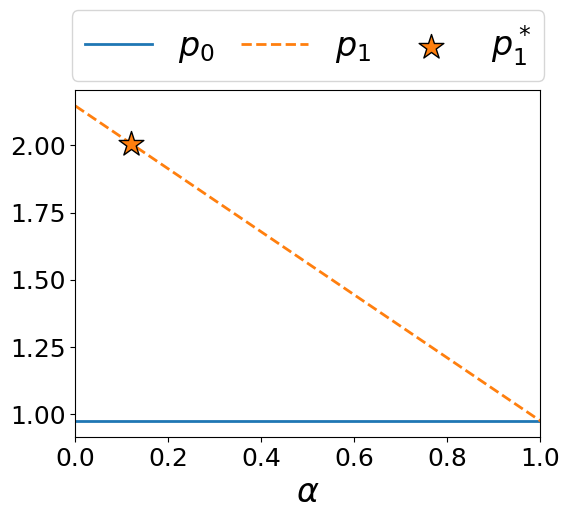

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4.5))

plt.plot(alpha_list, p0_list, label=r'$p_0$', color='tab:blue', linestyle='-', linewidth=2)
plt.plot(alpha_list, p1_list, label=r'$p_1$', color='tab:orange', linestyle='--', linewidth=2)

p1_array = np.array(p1_list)
idx = (np.abs(p1_array - 2.0)).argmin()

alpha_at_2 = alpha_list[idx]
p1_at_2 = p1_list[idx]

plt.scatter(alpha_at_2, p1_at_2,
            color='tab:orange',
            marker='*',
            s=350,
            edgecolors='black',
            linewidths=1,
            label=r'$p_1^* $',
            zorder=5)

plt.xlim([0, 1])

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.28),
    ncol=3,
    fontsize=24,
    columnspacing=0.8
)

ax.set_xlabel(r'$\alpha$', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=18)

plt.savefig('rawlsian_ex_price.pdf', format='pdf', bbox_inches='tight')
files.download('rawlsian_ex_price.pdf')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

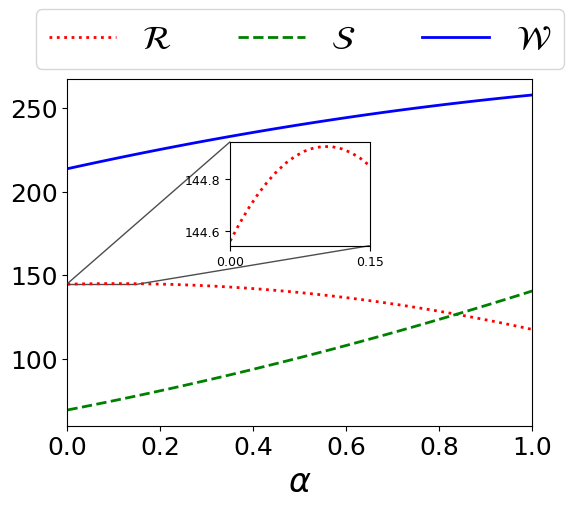

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(6,4.5))

# main
ax.plot(alpha_list, R_list, color='red', label=r'$\mathcal{R}$', linestyle=':', linewidth=2)
ax.plot(alpha_list, S_list, color='green', label=r'$\mathcal{S}$', linestyle='--', linewidth=2)
ax.plot(alpha_list, W_list, color='blue', label=r'$\mathcal{W}$', linewidth=2)
ax.set_xlim(0, 1)
# ax.set_title('Full range')

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=3,
    fontsize=24,
    # frameon=False
)

# indices for alpha in [0, 0.1]
alpha_arr = np.asarray(alpha_list)
mask = alpha_arr <= 0.15

# inset (move to upper right to avoid blocking)
axins = inset_axes(ax, width="30%", height="30%", loc='upper center', borderpad=4.5)

axins.plot(alpha_arr[mask], np.asarray(R_list)[mask], color='red', linestyle=':', linewidth=2)
axins.set_xlim(0, 0.15)

r_zoom = np.asarray(R_list)[mask]
pad = 0.05 * (r_zoom.max() - r_zoom.min() + 1e-9)
axins.set_ylim(r_zoom.min() - pad, r_zoom.max() + pad)

axins.set_xticks([0, 0.15])
axins.tick_params(labelsize=9)

# show zoom box + connectors
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.3")

ax.set_xlabel(r'$\alpha$', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=18)

plt.savefig('rawlsian_ex_price_outcomes.pdf', format='pdf', bbox_inches='tight')
files.download('rawlsian_ex_price_outcomes.pdf')
plt.show()


In [ ]:
print(p0_LS, p1_LS)
d0 = 1 + b0 * p0_LS
d1 = 1 + b1 * p1_LS
print(d0, d1)

0.9758645422866735 2.1457694605594253
0.5120677288566633 0.4635576348601437


In [ ]:
alpha_list = [i/100 for i in range(101)]
p0_list, p1_list = [], []
d0_list, d1_list = [], []
p0_LS, p1_LS = -1/(2*b0_hat), -1/(2*b1_hat)
R_list, S_list, W_list = [], [], []
for alpha in alpha_list:
    #_p0, _p1 = (1-alpha) * p0_LS + alpha * (1/1 * b1_hat/b0_hat) * p1_LS, p1_LS
    _p0, _p1 = p0_LS, (1-alpha) * p1_LS + alpha * b0/b1 * p0_LS
    p0_list.append(p0_LS)
    p1_list.append(_p1)
    d0_list.append(1 + b0 * _p0)
    d1_list.append(1 + b1 * _p1)
    # d0_list.append(1 + b0_hat * _p0)
    # d1_list.append(1 + b1_hat * _p1)
    rev = n0 * max(0, _p0-c) * max(0, 1+_p0*b0) + n1 * max(0, _p1-c) * max(0, 1+_p1*b1)
    sur = n0  * 1/2 * (-1/b0 - _p0) * (1 + b0 * _p0) + n1 * 1/2 * (-1/b1 - _p1) * (1 + b1 * _p1)
    R_list.append(rev)
    S_list.append(sur)
    W_list.append(rev+sur)

In [ ]:
print(1 + b0 * p0_LS, 1 + b1 * p1_LS)

0.5120677288566633 0.4635576348601437


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

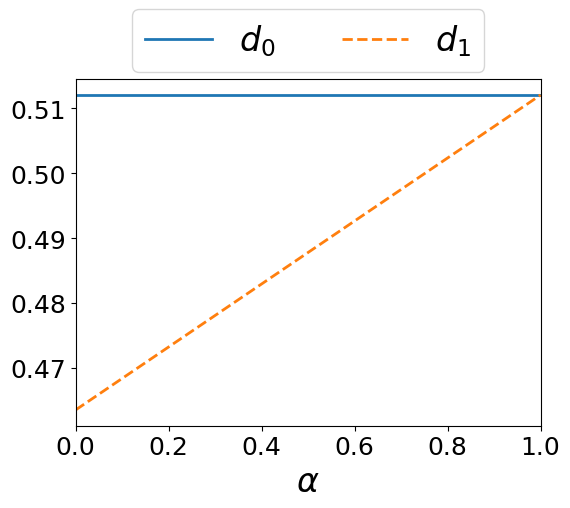

In [ ]:
fig, ax = plt.subplots(figsize=(6,4.5))
plt.plot(alpha_list, d0_list, label=r'$d_0$', color='tab:blue', linewidth=2)
plt.plot(alpha_list, d1_list, label=r'$d_1$', color='tab:orange', linestyle='--', linewidth=2)
plt.xlim([0,1])
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    fontsize=24,
    # frameon=False
)
ax.set_xlabel(r'$\alpha$', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=18)

plt.savefig('rawlsian_ex_demand.pdf', format='pdf', bbox_inches='tight')
files.download('rawlsian_ex_demand.pdf')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

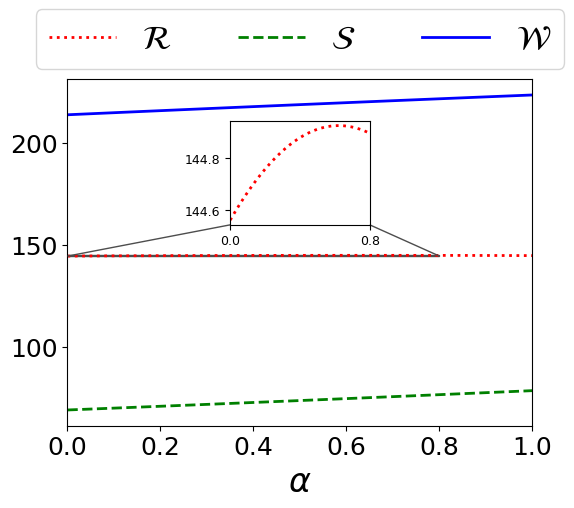

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(6,4.5))

# main
ax.plot(alpha_list, R_list, color='red', label=r'$\mathcal{R}$', linestyle=':', linewidth=2)
ax.plot(alpha_list, S_list, color='green', label=r'$\mathcal{S}$', linestyle='--', linewidth=2)
ax.plot(alpha_list, W_list, color='blue', label=r'$\mathcal{W}$', linewidth=2)
ax.set_xlim(0, 1)
# ax.set_title('Full range')

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=3,
    fontsize=24,
    # frameon=False
)

# indices for alpha in [0, 0.1]
alpha_arr = np.asarray(alpha_list)
mask = alpha_arr <= 0.8

# inset (move to upper right to avoid blocking)
axins = inset_axes(ax, width="30%", height="30%", loc='upper center', borderpad=3)

axins.plot(alpha_arr[mask], np.asarray(R_list)[mask], color='red', linestyle=':', linewidth=2)
axins.set_xlim(0, 0.8)

r_zoom = np.asarray(R_list)[mask]
pad = 0.05 * (r_zoom.max() - r_zoom.min() + 1e-9)
axins.set_ylim(r_zoom.min() - pad, r_zoom.max() + pad)

axins.set_xticks([0, 0.8])
axins.tick_params(labelsize=9)

# show zoom box + connectors
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.3")

ax.set_xlabel(r'$\alpha$', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=18)

plt.savefig('rawlsian_ex_demand_outcomes.pdf', format='pdf', bbox_inches='tight')
files.download('rawlsian_ex_demand_outcomes.pdf')
plt.show()


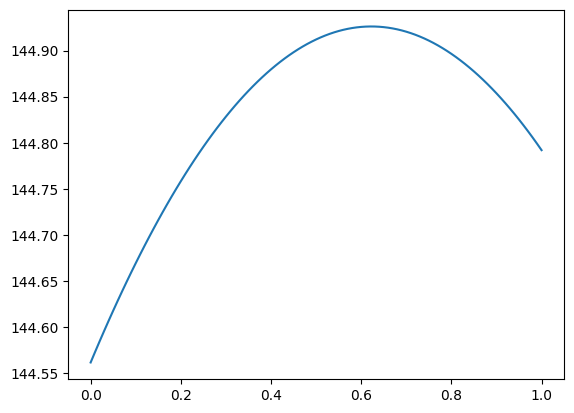

In [ ]:
plt.plot(alpha_list, R_list)